# 💰 Personal Finance Calculator

A personal project by **Anupam Kumar** — a small toolkit for the money questions I actually
ask myself: *Am I saving enough? What does this loan really cost? Will super get me there?
How far am I from financial independence?*

Everything is built from first principles with clearly labelled assumptions, so you can drop in
your own numbers and see the result. Figures are in **AUD** and the superannuation logic follows
the Australian system, but the maths is universal.

**Contents**
1. Budget split (50/30/20)
2. Savings goal & compound growth
3. Loan / mortgage repayments
4. Superannuation projection
5. Net worth & financial independence (FIRE)

> *This is a personal learning project, not financial advice.*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 13

AUD = lambda x: f"${x:,.0f}"   # quick currency formatter
print("Ready.")

Ready.


## 1. Budget split — the 50/30/20 rule

A simple, well-known guideline: **50%** of after-tax income to *needs*, **30%** to *wants*,
and **20%** to *savings & debt repayment*. It's a starting frame, not a law — but it's a fast way
to sanity-check where the money goes.


Needs            $4,250  /month
Wants            $2,550  /month
Savings & debt   $1,700  /month


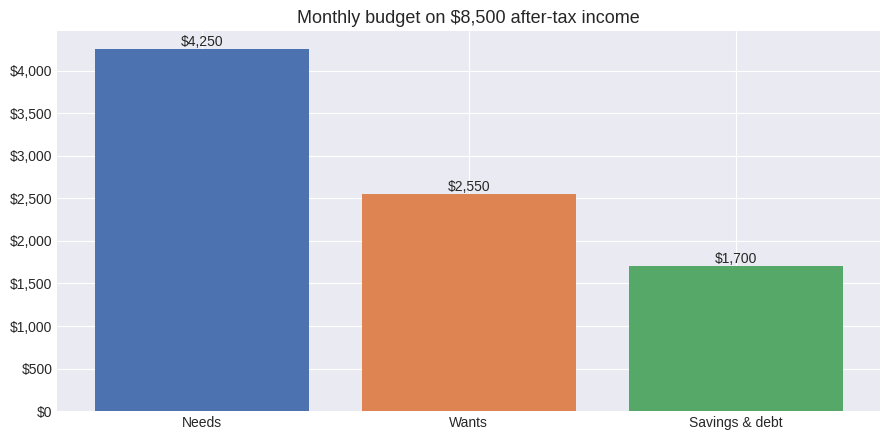

In [2]:
def budget_split(monthly_income_after_tax, needs=0.50, wants=0.30, savings=0.20):
    parts = {"Needs": needs, "Wants": wants, "Savings & debt": savings}
    return {k: monthly_income_after_tax * v for k, v in parts.items()}

monthly_income = 8500     # <-- your monthly after-tax income (AUD)
split = budget_split(monthly_income)

for k, v in split.items():
    print(f"{k:<16} {AUD(v)}  /month")

fig, ax = plt.subplots()
ax.bar(split.keys(), split.values(), color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title(f"Monthly budget on {AUD(monthly_income)} after-tax income")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: AUD(x)))
for i, v in enumerate(split.values()):
    ax.text(i, v, AUD(v), ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 2. Savings goal & compound growth

How a pot of money grows when you contribute regularly and let compounding work. This is the
future value of an initial balance plus a recurring monthly contribution, compounded monthly.

$$FV = P(1+r)^n + C\left[\frac{(1+r)^n - 1}{r}\right]$$

where \(P\) = starting balance, \(C\) = monthly contribution, \(r\) = monthly return,
\(n\) = number of months.


After 20 years:
  You contributed : $380,000
  Ending balance  : $862,165
  Growth (interest): $482,165


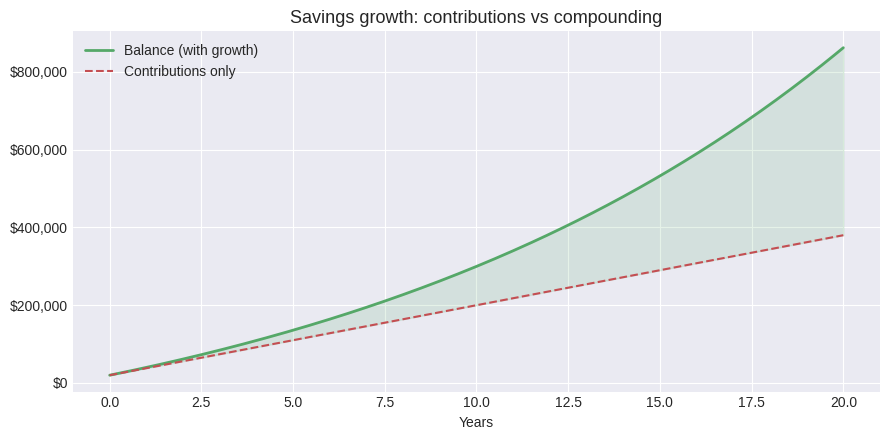

In [3]:
def savings_projection(start, monthly_contrib, annual_return, years):
    r = annual_return / 12
    n = years * 12
    months = np.arange(n + 1)
    balance = start * (1 + r) ** months + monthly_contrib * (((1 + r) ** months - 1) / r)
    contributed = start + monthly_contrib * months
    return pd.DataFrame({"month": months, "balance": balance, "contributed": contributed})

df = savings_projection(start=20_000, monthly_contrib=1_500, annual_return=0.07, years=20)

final = df.iloc[-1]
print(f"After 20 years:")
print(f"  You contributed : {AUD(final.contributed)}")
print(f"  Ending balance  : {AUD(final.balance)}")
print(f"  Growth (interest): {AUD(final.balance - final.contributed)}")

fig, ax = plt.subplots()
yrs = df.month / 12
ax.plot(yrs, df.balance, label="Balance (with growth)", color="#55A868", lw=2)
ax.plot(yrs, df.contributed, label="Contributions only", color="#C44E52", ls="--")
ax.fill_between(yrs, df.contributed, df.balance, alpha=0.15, color="#55A868")
ax.set_title("Savings growth: contributions vs compounding")
ax.set_xlabel("Years"); ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: AUD(x)))
plt.tight_layout(); plt.show()

## 3. Loan / mortgage repayments

The standard amortising-loan formula gives the fixed monthly repayment, then we build the full
schedule to see how much of each payment is *interest* vs *principal* — and the total interest
paid over the life of the loan.

$$M = P\,\frac{r(1+r)^n}{(1+r)^n - 1}$$


Monthly repayment : $4,594
Total repaid      : $1,653,666
Total interest    : $903,666  (120% of the loan)


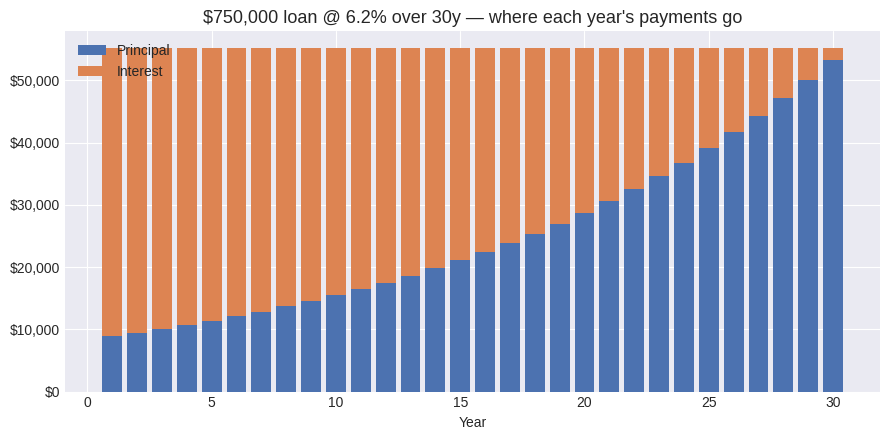

In [4]:
def amortisation(principal, annual_rate, years):
    r = annual_rate / 12
    n = years * 12
    M = principal * (r * (1 + r) ** n) / ((1 + r) ** n - 1)
    rows, balance = [], principal
    for m in range(1, n + 1):
        interest = balance * r
        principal_paid = M - interest
        balance -= principal_paid
        rows.append((m, M, interest, principal_paid, max(balance, 0)))
    sched = pd.DataFrame(rows, columns=["month", "payment", "interest", "principal", "balance"])
    return M, sched

loan = 750_000       # amount borrowed (AUD)
rate = 0.062         # annual interest rate
term = 30            # years

M, sched = amortisation(loan, rate, term)
total_paid = M * term * 12
print(f"Monthly repayment : {AUD(M)}")
print(f"Total repaid      : {AUD(total_paid)}")
print(f"Total interest    : {AUD(total_paid - loan)}  ({(total_paid-loan)/loan:.0%} of the loan)")

yearly = sched.groupby((sched.month - 1) // 12 + 1)[["interest", "principal"]].sum()
fig, ax = plt.subplots()
ax.bar(yearly.index, yearly.principal, label="Principal", color="#4C72B0")
ax.bar(yearly.index, yearly.interest, bottom=yearly.principal, label="Interest", color="#DD8452")
ax.set_title(f"{AUD(loan)} loan @ {rate:.1%} over {term}y — where each year's payments go")
ax.set_xlabel("Year"); ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: AUD(x)))
plt.tight_layout(); plt.show()

## 4. Superannuation projection (Australia)

Projects a super balance to retirement using employer contributions (the Super Guarantee, currently
**11.5%** of salary), optional salary sacrifice, wage growth, and an assumed net return. A rough but
useful picture of the retirement pot.


Projected super at 67: $3,625,065


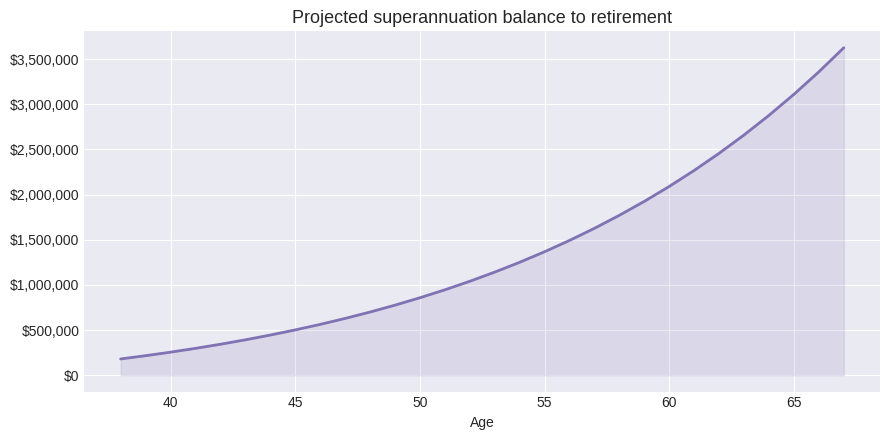

In [5]:
def super_projection(salary, start_balance, sg_rate=0.115, extra_annual=0,
                     wage_growth=0.03, net_return=0.065, current_age=38, retire_age=67):
    years = retire_age - current_age
    balance, sal = start_balance, salary
    history = [(current_age, balance)]
    for _ in range(years):
        contrib = sal * sg_rate + extra_annual
        balance = balance * (1 + net_return) + contrib
        sal *= (1 + wage_growth)
        history.append((history[-1][0] + 1, balance))
    return pd.DataFrame(history, columns=["age", "balance"])

sup = super_projection(salary=160_000, start_balance=180_000, extra_annual=6_000)
print(f"Projected super at 67: {AUD(sup.iloc[-1].balance)}")

fig, ax = plt.subplots()
ax.plot(sup.age, sup.balance, color="#8172B3", lw=2)
ax.fill_between(sup.age, 0, sup.balance, alpha=0.15, color="#8172B3")
ax.set_title("Projected superannuation balance to retirement")
ax.set_xlabel("Age")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: AUD(x)))
plt.tight_layout(); plt.show()

## 5. Net worth & financial independence (FIRE)

The **4% rule** suggests you can sustainably draw ~4% of a portfolio per year, so your
"financial independence number" is roughly *annual spending × 25*. Here we estimate how many years
of investing it takes to get there.


Annual spending      : $75,000
FI number (25x)      : $1,875,000
Reach FI in ~17.2 years at current savings rate


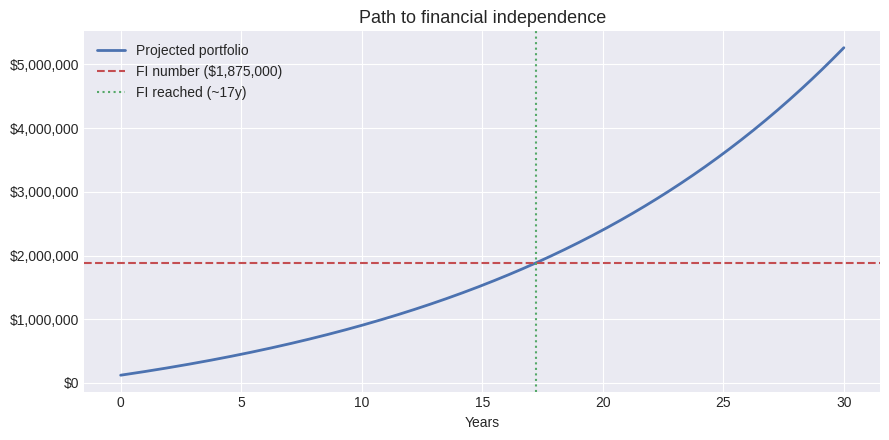

In [6]:
annual_spend = 75_000
fi_number = annual_spend * 25
print(f"Annual spending      : {AUD(annual_spend)}")
print(f"FI number (25x)      : {AUD(fi_number)}")

proj = savings_projection(start=120_000, monthly_contrib=4_000, annual_return=0.065, years=30)
hit = proj[proj.balance >= fi_number]
if not hit.empty:
    yrs_to_fi = hit.iloc[0].month / 12
    print(f"Reach FI in ~{yrs_to_fi:.1f} years at current savings rate")

fig, ax = plt.subplots()
yrs = proj.month / 12
ax.plot(yrs, proj.balance, color="#4C72B0", lw=2, label="Projected portfolio")
ax.axhline(fi_number, color="#C44E52", ls="--", label=f"FI number ({AUD(fi_number)})")
if not hit.empty:
    ax.axvline(yrs_to_fi, color="#55A868", ls=":", label=f"FI reached (~{yrs_to_fi:.0f}y)")
ax.set_title("Path to financial independence")
ax.set_xlabel("Years"); ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: AUD(x)))
plt.tight_layout(); plt.show()

---

### Wrap-up

Five small models, one theme: make the trade-offs visible. Change the assumptions at the top of
each cell to fit your own situation and the charts update.

*Built as a personal project while studying Applied Finance. Not financial advice.*
